# Notebook 02: Chunking Strategy Analysis

**CRISP-DM Phase: Data Preparation**

This notebook compares different text chunking strategies:
1. **Fixed-size chunking** — splits at exact character boundaries
2. **Recursive chunking** — splits hierarchically (paragraphs → sentences → words)
3. **Sentence-based chunking** — groups complete sentences

We evaluate each strategy on chunk count, size distribution, and semantic coherence.

In [1]:
# Standard imports
import sys
import json
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import CHUNKING_EXPERIMENTS, FIGURES_DIR, METRICS_DIR
from src.data_loader import load_all_documents
from src.chunker import (
    chunk_all_documents, get_chunk_stats,
    chunk_fixed_size, chunk_recursive, chunk_sentence_based,
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load documents
documents = load_all_documents()
print(f"Loaded {len(documents)} documents")

2026-04-09 12:24:56,831 - rag_qa_system - INFO - Loaded PDF with PyPDF2: CCAC-AR2026-2-our-changing-climate-final.pdf (33 pages)


2026-04-09 12:24:56,837 - rag_qa_system - INFO -   Loaded: CCAC-AR2026-2-our-changing-climate-final.pdf (11504 words)


2026-04-09 12:25:02,185 - rag_qa_system - INFO - Loaded PDF with PyPDF2: Energy-in-Ireland-2025.pdf (238 pages)


2026-04-09 12:25:02,217 - rag_qa_system - INFO -   Loaded: Energy-in-Ireland-2025.pdf (60874 words)


2026-04-09 12:25:02,226 - rag_qa_system - INFO - Loaded text file: carbon_capture_and_storage.txt (43957 chars)


...

2026-04-09 12:25:05,777 - rag_qa_system - INFO -   Loaded: sustainable_energy_authority_of_ireland.txt (348 words)


2026-04-09 12:25:05,777 - rag_qa_system - INFO - Loaded text file: transport_in_ireland.txt (15348 chars)


2026-04-09 12:25:05,779 - rag_qa_system - INFO -   Loaded: transport_in_ireland.txt (2423 words)


2026-04-09 12:25:05,779 - rag_qa_system - INFO - Total documents loaded: 14


Loaded 14 documents


## 2.1 Run Chunking Experiments

Apply each chunking configuration to the full corpus and collect statistics.

In [3]:
# Run all chunking experiments defined in config
experiment_results = []

for exp in CHUNKING_EXPERIMENTS:
    print(f"\nExperiment: {exp['strategy']} (size={exp['chunk_size']}, overlap={exp['chunk_overlap']})")
    
    # Chunk all documents with this configuration
    chunks = chunk_all_documents(
        documents,
        strategy=exp['strategy'],
        chunk_size=exp['chunk_size'],
        chunk_overlap=exp['chunk_overlap'],
    )
    
    # Get statistics
    stats = get_chunk_stats(chunks)
    stats['config'] = f"{exp['strategy']}_{exp['chunk_size']}_{exp['chunk_overlap']}"
    experiment_results.append(stats)
    
    print(f"  Chunks: {stats['num_chunks']}")
    print(f"  Avg chars: {stats['avg_chars']:.0f}")
    print(f"  Min/Max chars: {stats['min_chars']}/{stats['max_chars']}")

print("\n✅ All chunking experiments complete")

2026-04-09 12:25:05,783 - rag_qa_system - INFO - Chunked 'CCAC-AR2026-2-our-changing-climate-final.pdf' with strategy='fixed': 182 chunks (size=512, overlap=50)


2026-04-09 12:25:05,784 - rag_qa_system - INFO - Chunked 'Energy-in-Ireland-2025.pdf' with strategy='fixed': 867 chunks (size=512, overlap=50)


2026-04-09 12:25:05,785 - rag_qa_system - INFO - Chunked 'carbon_capture_and_storage.txt' with strategy='fixed': 95 chunks (size=512, overlap=50)


2026-04-09 12:25:05,787 - rag_qa_system - INFO - Chunked 'climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf' with strategy='fixed': 1515 chunks (size=512, overlap=50)


2026-04-09 12:25:05,787 - rag_qa_system - INFO - Chunked 'climate_change_in_europe.txt' with strategy='fixed': 105 chunks (size=512, overlap=50)


...

2026-04-09 12:25:06,110 - rag_qa_system - INFO - Chunked 'paris_agreement.txt' with strategy='sentence': 47 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,111 - rag_qa_system - INFO - Chunked 'sustainable_energy_authority_of_ireland.txt' with strategy='sentence': 3 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,111 - rag_qa_system - INFO - Chunked 'transport_in_ireland.txt' with strategy='sentence': 20 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,111 - rag_qa_system - INFO - Total chunks from 14 documents: 1803


  Chunks: 2096
  Avg chars: 729
  Min/Max chars: 10/999

Experiment: sentence (size=1000, overlap=200)
  Chunks: 1803
  Avg chars: 940
  Min/Max chars: 73/7522

✅ All chunking experiments complete


In [4]:
# Create comparison DataFrame
results_df = pd.DataFrame(experiment_results)
results_df = results_df[['config', 'strategy', 'num_chunks', 'avg_chars', 
                         'min_chars', 'max_chars', 'avg_words']]
results_df.columns = ['Configuration', 'Strategy', 'Num Chunks', 'Avg Chars',
                      'Min Chars', 'Max Chars', 'Avg Words']

print("\nChunking Strategy Comparison:")
print(results_df.to_string(index=False))


Chunking Strategy Comparison:
     Configuration  Strategy  Num Chunks   Avg Chars  Min Chars  Max Chars  Avg Words
      fixed_512_50     fixed        3320  510.603916         58        512  80.453313
    fixed_1024_100     fixed        1665 1018.326727        118       1024 159.647447
  recursive_500_50 recursive        4131  369.275720          7        499  57.914549
recursive_1000_200 recursive        2096  728.785782         10        999 114.033874
 sentence_1000_200  sentence        1803  940.185801         73       7522 147.825846


## 2.2 Visualization: Chunk Size Distributions

2026-04-09 12:25:06,173 - rag_qa_system - INFO - Chunked 'CCAC-AR2026-2-our-changing-climate-final.pdf' with strategy='fixed': 182 chunks (size=512, overlap=50)


2026-04-09 12:25:06,174 - rag_qa_system - INFO - Chunked 'Energy-in-Ireland-2025.pdf' with strategy='fixed': 867 chunks (size=512, overlap=50)


2026-04-09 12:25:06,174 - rag_qa_system - INFO - Chunked 'carbon_capture_and_storage.txt' with strategy='fixed': 95 chunks (size=512, overlap=50)


2026-04-09 12:25:06,176 - rag_qa_system - INFO - Chunked 'climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf' with strategy='fixed': 1515 chunks (size=512, overlap=50)


2026-04-09 12:25:06,176 - rag_qa_system - INFO - Chunked 'climate_change_in_europe.txt' with strategy='fixed': 105 chunks (size=512, overlap=50)


...

2026-04-09 12:25:06,447 - rag_qa_system - INFO - Chunked 'european_green_deal.txt' with strategy='sentence': 64 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,448 - rag_qa_system - INFO - Chunked 'paris_agreement.txt' with strategy='sentence': 47 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,449 - rag_qa_system - INFO - Chunked 'sustainable_energy_authority_of_ireland.txt' with strategy='sentence': 3 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,449 - rag_qa_system - INFO - Chunked 'transport_in_ireland.txt' with strategy='sentence': 20 chunks (size=1000, overlap=200)


2026-04-09 12:25:06,449 - rag_qa_system - INFO - Total chunks from 14 documents: 1803


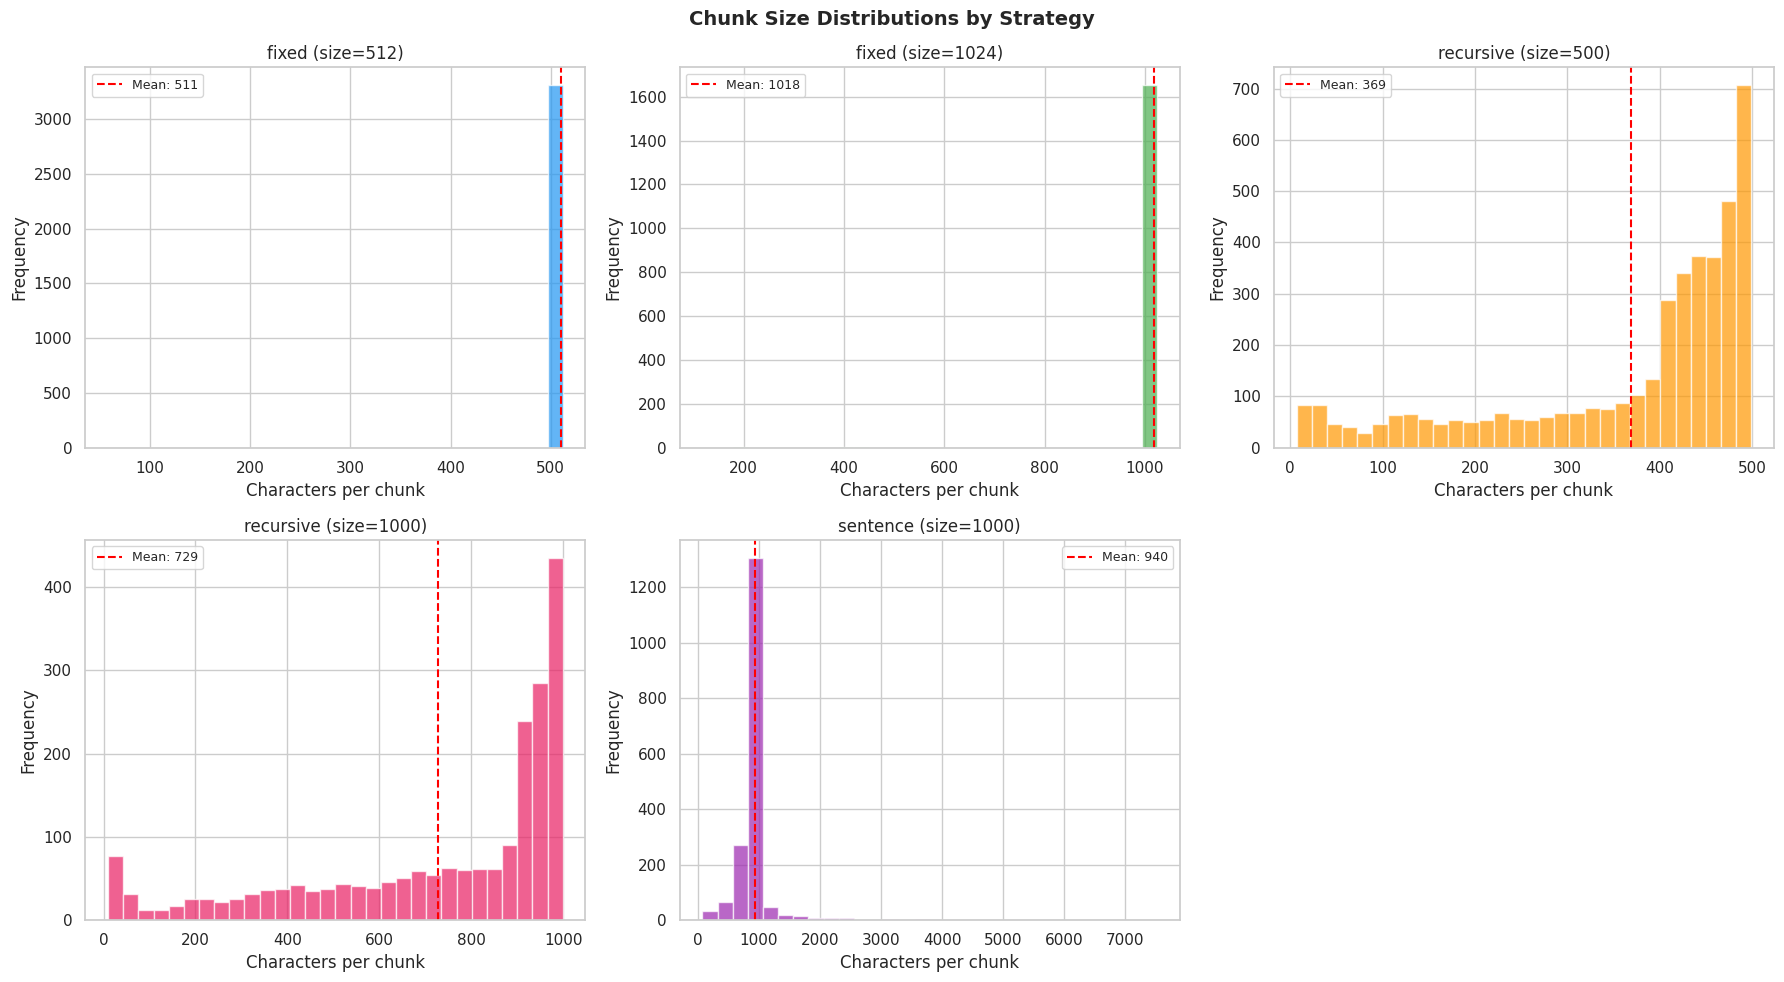

In [5]:
# Visualize chunk size distributions for each strategy
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, exp in enumerate(CHUNKING_EXPERIMENTS):
    chunks = chunk_all_documents(
        documents,
        strategy=exp['strategy'],
        chunk_size=exp['chunk_size'],
        chunk_overlap=exp['chunk_overlap'],
    )
    
    char_counts = [c.char_count for c in chunks]
    
    ax = axes[i]
    ax.hist(char_counts, bins=30, color=colors[i], alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(char_counts), color='red', linestyle='--', label=f'Mean: {np.mean(char_counts):.0f}')
    ax.set_title(f"{exp['strategy']} (size={exp['chunk_size']})")
    ax.set_xlabel('Characters per chunk')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

# Hide unused subplot
if len(CHUNKING_EXPERIMENTS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Chunk Size Distributions by Strategy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'chunking_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

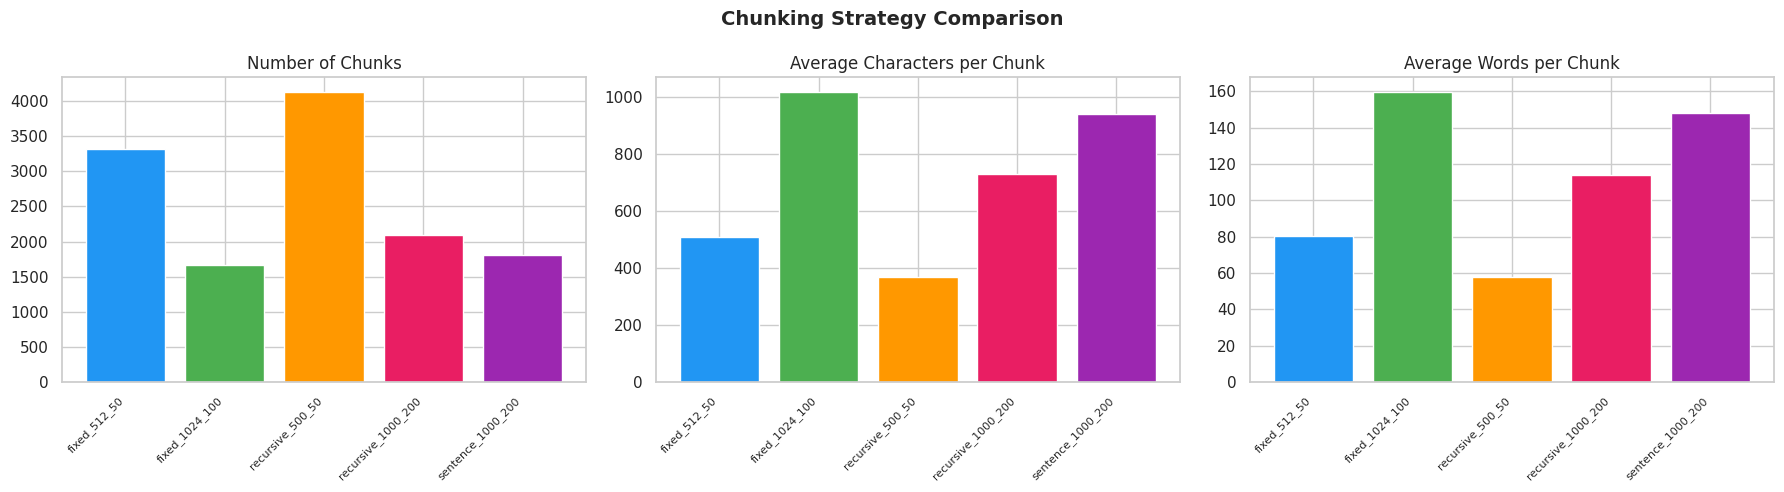

In [6]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = results_df['Configuration'].values
x = range(len(configs))

# Number of chunks
axes[0].bar(x, results_df['Num Chunks'], color=colors[:len(configs)])
axes[0].set_title('Number of Chunks')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)

# Average characters
axes[1].bar(x, results_df['Avg Chars'], color=colors[:len(configs)])
axes[1].set_title('Average Characters per Chunk')
axes[1].set_xticks(x)
axes[1].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)

# Average words
axes[2].bar(x, results_df['Avg Words'], color=colors[:len(configs)])
axes[2].set_title('Average Words per Chunk')
axes[2].set_xticks(x)
axes[2].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)

plt.suptitle('Chunking Strategy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'chunking_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Sample Chunks

Inspect sample chunks from each strategy to assess semantic quality.

In [7]:
# Show sample chunks from each strategy
for exp in CHUNKING_EXPERIMENTS[:3]:  # Show first 3 strategies
    chunks = chunk_all_documents(
        documents,
        strategy=exp['strategy'],
        chunk_size=exp['chunk_size'],
        chunk_overlap=exp['chunk_overlap'],
    )
    
    print(f"\n{'='*60}")
    print(f"Strategy: {exp['strategy']} (size={exp['chunk_size']})")
    print(f"{'='*60}")
    print(f"\nSample Chunk (#{chunks[0].chunk_id}):")
    print(f"{chunks[0].text[:300]}...")
    print(f"\n[{chunks[0].word_count} words, {chunks[0].char_count} chars]")

2026-04-09 12:25:07,874 - rag_qa_system - INFO - Chunked 'CCAC-AR2026-2-our-changing-climate-final.pdf' with strategy='fixed': 182 chunks (size=512, overlap=50)


2026-04-09 12:25:07,875 - rag_qa_system - INFO - Chunked 'Energy-in-Ireland-2025.pdf' with strategy='fixed': 867 chunks (size=512, overlap=50)


2026-04-09 12:25:07,875 - rag_qa_system - INFO - Chunked 'carbon_capture_and_storage.txt' with strategy='fixed': 95 chunks (size=512, overlap=50)


2026-04-09 12:25:07,877 - rag_qa_system - INFO - Chunked 'climate-action-plan-2023-8b7dba92-f397-4163-8293-3aea656f6b5f.pdf' with strategy='fixed': 1515 chunks (size=512, overlap=50)


2026-04-09 12:25:07,877 - rag_qa_system - INFO - Chunked 'climate_change_in_europe.txt' with strategy='fixed': 105 chunks (size=512, overlap=50)


...

2026-04-09 12:25:08,008 - rag_qa_system - INFO - Chunked 'paris_agreement.txt' with strategy='recursive': 131 chunks (size=500, overlap=50)


2026-04-09 12:25:08,008 - rag_qa_system - INFO - Chunked 'sustainable_energy_authority_of_ireland.txt' with strategy='recursive': 10 chunks (size=500, overlap=50)


2026-04-09 12:25:08,009 - rag_qa_system - INFO - Chunked 'transport_in_ireland.txt' with strategy='recursive': 48 chunks (size=500, overlap=50)


2026-04-09 12:25:08,009 - rag_qa_system - INFO - Total chunks from 14 documents: 4131



Strategy: fixed (size=512)

Sample Chunk (#0):
ANNUAL REVIEW 2026
Our Changing
Climate in 2025

Annual Review 2026:
Our Changing Climate in 2025
Submitted to the Minister for Climate, Energy and the Environment
on 27 March 2026
Climate Change Advisory Council
McCumiskey House
Richview, Clonskeagh Road, Dublin 14, D14 YR62
Tel: 01 2680180
Email: ...

[74 words, 512 chars]

Strategy: fixed (size=1024)

Sample Chunk (#0):
ANNUAL REVIEW 2026
Our Changing
Climate in 2025

Annual Review 2026:
Our Changing Climate in 2025
Submitted to the Minister for Climate, Energy and the Environment
on 27 March 2026
Climate Change Advisory Council
McCumiskey House
Richview, Clonskeagh Road, Dublin 14, D14 YR62
Tel: 01 2680180
Email: ...

[139 words, 1023 chars]

Strategy: recursive (size=500)

Sample Chunk (#0):
ANNUAL REVIEW 2026
Our Changing
Climate in 2025...

[8 words, 47 chars]


In [8]:
# Save experiment results
with open(METRICS_DIR / 'chunking_experiment_results.json', 'w') as f:
    json.dump(experiment_results, f, indent=2, default=str)

print("✅ Results saved to results/metrics/chunking_experiment_results.json")

✅ Results saved to results/metrics/chunking_experiment_results.json


## 2.4 Summary

✅ Compared 5 chunking configurations  
✅ Visualized chunk size distributions  
✅ Inspected sample chunks for semantic quality  
✅ Saved experiment results  

**Selected strategy for main pipeline**: `recursive` with size=1000, overlap=200  
**Rationale**: Best balance of chunk count and semantic coherence  

**Next**: Notebook 03 — Embedding Comparison